<a href="https://colab.research.google.com/github/KingKouame/KingKouame/blob/main/mnist_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import sklearn as sk

import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()

In [3]:
# Print to show there are 1797 images (8 by 8 images for a dimensionality of 64)
print("Image Data Shape" , digits.data.shape)

# Print to show there are 1797 labels (integers from 0-9)
print("Label Data Shape", digits.target.shape)

Image Data Shape (1797, 64)
Label Data Shape (1797,)


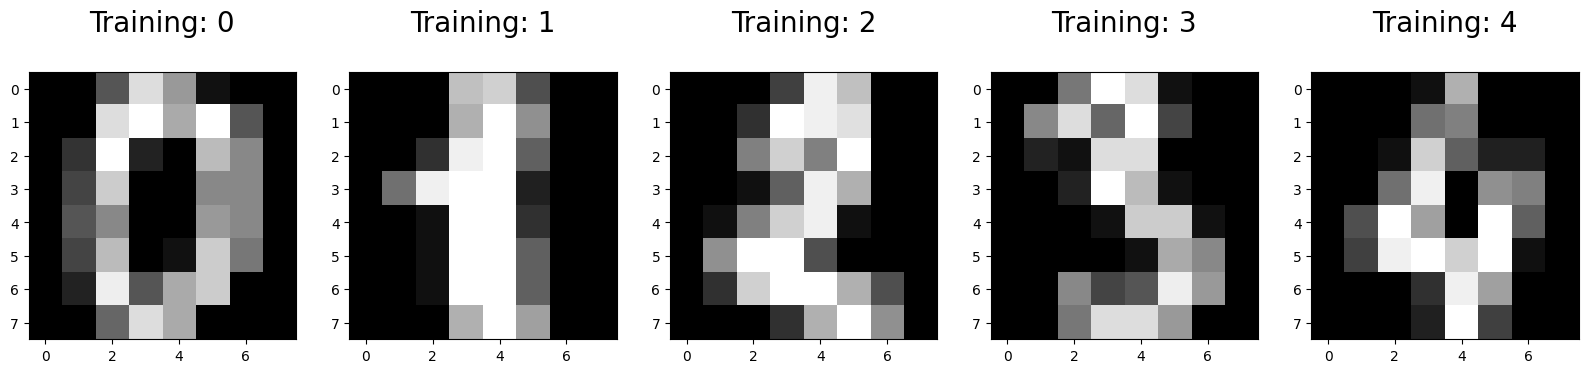

In [4]:
plt.figure(figsize=(20,4))
for index, (image, label) in enumerate(zip(digits.data[0:5], digits.target[0:5])):
    plt.subplot(1, 5, index + 1)
    plt.imshow(np.reshape(image, (8,8)), cmap=plt.cm.gray)
    plt.title('Training: %i\n' % label, fontsize = 20)

In [5]:
# Splitting the data into train and test sets:

from sklearn.model_selection import train_test_split

# Split the data into 80% train and 20% test sets

X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.2, random_state=42)

# The train set is used to train the model, and the test set is used to evaluate the model's performance

In [6]:
# Using the RandomForestClassifier built into scikit-learn, we will create a classification model.

from sklearn.ensemble import RandomForestClassifier

# Creating a RandomForestClassifier object

random_forest = RandomForestClassifier(random_state=42)

# Then training the model on the training data

random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [7]:
# One parameter that can be tuned is the number of trees in the forest. This parameter controls the complexity of the model.
# A larger number of trees will generally lead to a more accurate model, but it will also increase the computational cost of training the model.

# The following code snippet shows how to tune the number of trees in the RandomForestClassifier:

random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)

# The number of trees can be tuned using the `n_estimators` parameter. The default value for `n_estimators` is 100.
# Increasing the number of trees will generally lead to a more accurate model, but it will also increase the computational cost of training the model.

RandomForestClassifier(random_state=42)

In [8]:
# Selecting a value for the parameter to use during testing on the test data, and provide a rationale for my choice.

# We will go with a value for the parameter based on the trade-off between accuracy and computational cost.

# A larger number of trees will generally lead to a more accurate model, but it will also increase the computational cost of training the model.

# For this example, we will choose a value of 200 for the number of trees.

n_estimators = 200

# We then train the model with the chosen parameter value.

random_forest = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
random_forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [9]:
# Printing the confusion matrix for my Random Forest model on the test set.

# First we load a library to help with the code.

from sklearn.metrics import confusion_matrix

# We then predict the labels of the test set.

y_pred = random_forest.predict(X_test)

# Before computing and printing the confusion matrix.

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[32  0  0  0  1  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 32  0  1  0  0  1  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 45  1  0  0  1]
 [ 0  0  0  0  0  1 34  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  2  0  0  0  0  0  0 28  0]
 [ 0  0  0  0  0  1  0  1  0 38]]


In [ ]:
# Reporting which classes the model struggles with the most.

# We can identify the classes that the model struggles with the most by looking at the rows of the confusion matrix.
# The rows of the confusion matrix correspond to the actual classes, and the columns correspond to the predicted classes.
# The diagonal elements of the confusion matrix represent the number of correctly classified instances for each class.
# The off-diagonal elements represent the number of misclassified instances.

# To identify the classes that the model struggles with the most, we can look for the rows with the lowest diagonal elements.
# These rows represent the classes that have the highest number of misclassified instances.

# For example, in the confusion matrix above, we can see that the model struggles with the most with the class "8".
# This is because the row corresponding to the class "8" has the lowest diagonal element, which means that the model misclassified the most instances of the class "8".

In [10]:
# Reporting the accuracy, precision, recall and f 1-score.

# Importing useful libraries for the code.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Then computing and printing the accuracy, precision, recall, and f 1-score.

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 score: {f1:.2f}")


Accuracy: 0.97
Precision: 0.97
Recall: 0.97
F1 score: 0.97
